# **Topic Modeling**

Topic modeling is a technique used in NLP to discover the abstract "topics" that occur in a collection of documents. It is a form of unsupervised learning that can help to identify patterns and themes in large text corpora.

## Why Topic Modeling?

The main usecase for topic modeling is to analyze large collections of text data, such as news articles, social media posts, or academic papers, to identify the main themes and topics that are being discussed.

There are several approaches to topic modeling, including statistical methods like Latent Dirichlet Allocation (LDA), as well as more recent approaches that leverage deep learning techniques, such as neural topic models and LLM-based topic modeling.

On neural topic models, we can use pre-trained language models (PLMs) to generate topic representations and to assign topics to documents. This can be done by fine-tuning a PLM on a topic modeling task, or by using the PLM to generate topic representations that can then be clustered or classified.

## BERTopic

[BERTopic](https://arxiv.org/abs/2203.05794) is a topic modeling technique that leverages pre-trained transformer-based language models to generate document embeddings, which are then clustered to identify topics. The class-based variation of TF-IDF is used to extract coherent topic representations from the clustered embeddings.

BERTopic implementation is provided in the `bertopic` [library](https://github.com/maartengr/bertopic), which can be installed via pip:

```bash
pip install bertopic
```

In [1]:
!pip install bertopic

# Suppress transformers logging
from transformers import logging

logging.set_verbosity_error()

Because we will be using language model that benefit from GPU, change the runtime to GPU (T4).

## Data Preparation

In this session, we will use the ArXiv abstracts dataset, which contains abstracts of scientific papers from the ArXiv repository. The dataset is provided with the helper function below, which will load the dataset and return it as a pandas DataFrame.

In [2]:
## No need to concern about this function
## This is helper for getting the arxiv abstracts dataset

from datasets import load_dataset
import pandas as pd
from functools import cache


@cache
def get_arxiv(nrows: int = 20_000) -> pd.DataFrame:
    # https://huggingface.co/datasets/gfissore/arxiv-abstracts-2021
    dataset = load_dataset(
        "gfissore/arxiv-abstracts-2021",
        split="train",
        streaming=True,
    )
    sample = dataset.take(nrows)

    return pd.DataFrame(list(sample))

In [3]:
arxiv = get_arxiv()
len(arxiv)

20000

In [4]:
arxiv.head(2)

,id,submitter,authors,title,comments,journal-ref,doi,abstract,report-no,categories,versions
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,A fully differential calculation in perturba...,ANL-HEP-PR-07-12,[hep-ph],"[v1, v2]"
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,NaN,NaN,"We describe a new algorithm, the $(k,\ell)$-...",NaN,[math.CO cs.CG],"[v1, v2]"


From this dataset, we will use the `abstract` column, which contains the abstracts of the papers, as the input for our topic modeling task.

Let's prepare the abstract data first. We check if the `abstract` column contains any missing values, and because there are none, we can proceed to split the data into training and testing sets.

In [5]:
# Check for missing values in the abstract column
arxiv["abstract"].isna().sum()

np.int64(0)

In [6]:
abstracts = arxiv["abstract"].tolist()

# Split the data into training and testing sets
TEST_SIZE = 1000

abstracts_train = abstracts[TEST_SIZE:]
abstracts_test = abstracts[:TEST_SIZE]

## Training Model

To train the BERTopic model, we can just call the `fit` method on the model instance, passing in the list of abstracts as the input. The model will then train on the abstracts and identify the underlying topics.

When running for the first time, the model will download the necessary pre-trained language model and other resources, so it may take some time to complete.

There are several parameters that can be set when initializing the BERTopic model, some of the important ones include:
- `language`: The language of the input text data, "english" or "multilingual". Default is "english".
- `top_n_words`: The number of top words to extract for each topic. Default is 10.
- `n_gram_range`: The range of n-grams to consider when extracting features from the text data. Default is (1, 1), which means only unigrams will be considered.
- `min_topic_size`: The minimum number of documents required to form a topic. Default is 10.
- `nr_topics`: The number of topics to extract. If set to None, the model will determine the optimal number of topics based on the data. Default is None.

For now we will use the default parameters and the `nr_topics=100` setting, but you can experiment with different values to see how it affects the results.

In [7]:
from bertopic import BERTopic

model = BERTopic(nr_topics=100).fit(abstracts_train)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

After training we can see the identified topics and their top words using the `get_topic_info` method, which will return a DataFrame containing the topic labels and their corresponding top words.

In [8]:
info = model.get_topic_info()

info.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7043,-1_of_the_in_is,"[of, the, in, is, to, and, we, for, that, on]",[ The numerical analysis of strongly interact...
1,0,3445,0_the_and_of_galaxies,"[the, and, of, galaxies, with, stars, from, to...",[ We have analyzed the bivariate distribution...
2,1,682,1_magnetic_temperature_superconducting_phase,"[magnetic, temperature, superconducting, phase...",[ We have studied the thermodynamic propertie...
3,2,422,2_phase_superfluid_lattice_condensate,"[phase, superfluid, lattice, condensate, trans...",[ A system with Bose-Einstein condensate is c...
4,3,401,3_neutrino_neutrinos_nuclear_nuclei,"[neutrino, neutrinos, nuclear, nuclei, mixing,...",[ We address the issue of the neutrino masses...


The topic value of -1 refers to all outliers and should typically be ignored. The method `visualize_barchart` can be used to visualize the top words for each topic in a bar chart format, which can help to better understand the identified topics and their associated keywords.

In [9]:
model.visualize_barchart()

## Analyzing Results

From the `info` DataFrame, we can then analyze the identified topics and their top words to gain insights into the underlying themes and patterns in the abstracts.

<Axes: xlabel='Topic'>

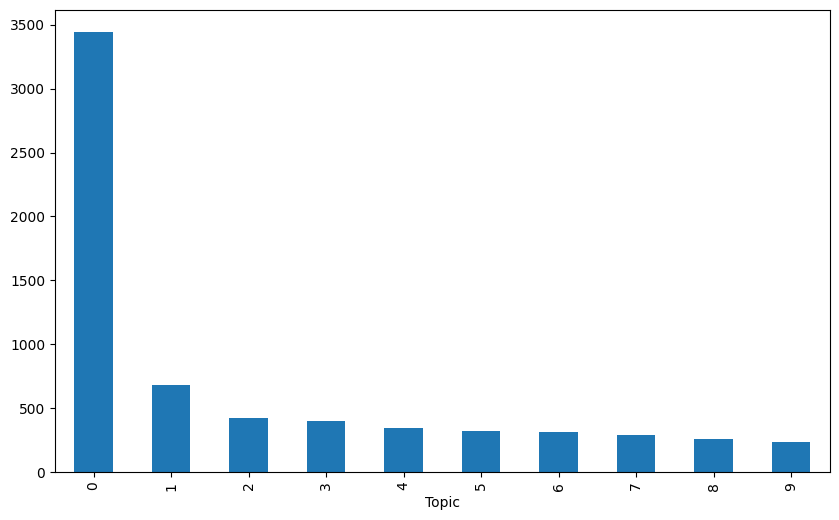

In [15]:
# Plot the top 10 topics by count
info[["Topic", "Count"]].iloc[1:11].plot.bar(
    x="Topic", y="Count", figsize=(10, 6), legend=False
)

We can also use the `get_topics` method to retrieve the top words for each topic with its corresponding probabilities

In [10]:
model.get_topics()

{-1: [('of', np.float64(0.00943957297396726)),
  ('the', np.float64(0.009421438758714132)),
  ('in', np.float64(0.008554588591029963)),
  ('is', np.float64(0.008330633513932614)),
  ('to', np.float64(0.008271638559870528)),
  ('and', np.float64(0.008207302417599191)),
  ('we', np.float64(0.008201045704123817)),
  ('for', np.float64(0.007870725340894077)),
  ('that', np.float64(0.007171069667265306)),
  ('on', np.float64(0.006910353313863509))],
 0: [('the', np.float64(0.009594549596953588)),
  ('and', np.float64(0.008782043867580873)),
  ('of', np.float64(0.008740389189062019)),
  ('galaxies', np.float64(0.00841916891224588)),
  ('with', np.float64(0.008148292088728911)),
  ('stars', np.float64(0.007918407061046557)),
  ('from', np.float64(0.007828593307522806)),
  ('to', np.float64(0.0078098951797446895)),
  ('in', np.float64(0.007776124102845541)),
  ('emission', np.float64(0.007218714339729352))],
 1: [('magnetic', np.float64(0.01777190518112732)),
  ('temperature', np.float64(0.014

We can also use the `find_topics` method to find the most relevant topics for a given query, which can help to understand how the identified topics relate to specific keywords or themes in the abstracts.

In [12]:
model.find_topics("arts")

([98, 77, 78, 40, 66],
 [np.float64(0.21392318844519043),
  np.float64(0.19448241228920432),
  np.float64(0.17722179709543345),
  np.float64(0.1385194444403162),
  np.float64(0.1348347139162884)])

## Classifying New Data

Let's classify new abstracts using the trained model. We can use the `transform` method to assign topics to new documents, which will return a list of topic labels for each document. This can be useful for categorizing new abstracts based on the identified topics from the training data.

We will use the test set of abstracts that we set aside earlier to evaluate the model's performance in classifying new data.

In [17]:
topics, probs = model.transform(abstracts_test)

test_df = pd.DataFrame(
    {"abstract": abstracts_test, "topic": topics, "probability": probs}
)
test_df.head()

,abstract,topic,probability
0,A fully differential calculation in perturba...,-1,0.000000
1,"We describe a new algorithm, the $(k,\ell)$-...",16,0.205498
2,The evolution of Earth-Moon system is descri...,0,0.801459
3,We show that a determinant of Stirling cycle...,87,0.967772
4,In this paper we show how to compute the $\L...,47,1.000000


The resulting topics is the topic label assigned to each abstract, while the probabilities represent the confidence of the model in assigning that topic to the abstract. We can create a new DataFrame to display the abstracts along with their assigned topics and probabilities for better data analysis.

<Axes: xlabel='topic'>

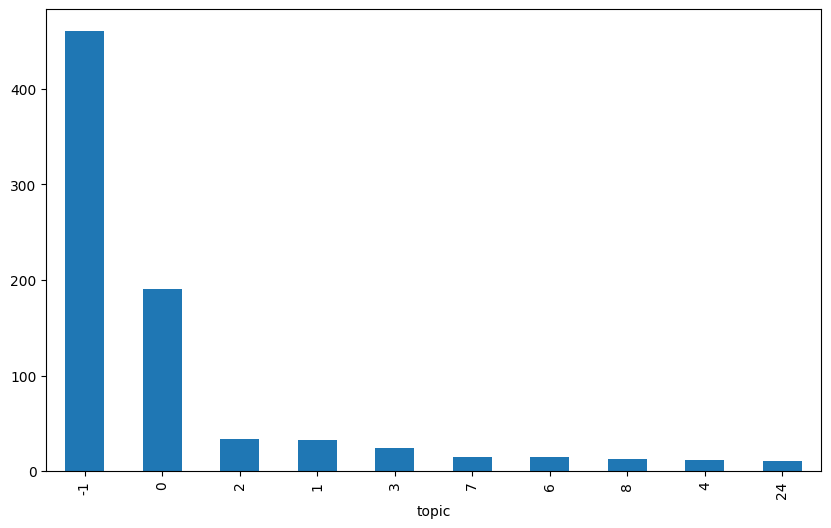

In [20]:
# Plot the topic counts for the test set
test_df["topic"].value_counts().sort_values(ascending=False)[:10].plot.bar(
    x="Topic", y="Count", figsize=(10, 6), legend=False
)

## Saving and Loading Model

It is also possible to save the trained BERTopic model to disk using the `save` method, which will allow you to reuse the model later without having to retrain it. You can load a saved model using the `load` method, which will return a new instance of the BERTopic model with the same parameters and trained weights as the original model.

In [21]:
# Save the model as a pickle file
save_path = "arxiv_bertopic.pkl"
model.save(save_path, serialization="pickle")

2026-04-15 13:20:38,692 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Then we can load the saved model and use it to classify new abstracts without having to retrain the model, which can save time and computational resources.

In [22]:
new_model = BERTopic.load(save_path)
new_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7043,-1_of_the_in_is,"[of, the, in, is, to, and, we, for, that, on]",[ The numerical analysis of strongly interact...
1,0,3445,0_the_and_of_galaxies,"[the, and, of, galaxies, with, stars, from, to...",[ We have analyzed the bivariate distribution...
2,1,682,1_magnetic_temperature_superconducting_phase,"[magnetic, temperature, superconducting, phase...",[ We have studied the thermodynamic propertie...
3,2,422,2_phase_superfluid_lattice_condensate,"[phase, superfluid, lattice, condensate, trans...",[ A system with Bose-Einstein condensate is c...
4,3,401,3_neutrino_neutrinos_nuclear_nuclei,"[neutrino, neutrinos, nuclear, nuclei, mixing,...",[ We address the issue of the neutrino masses...
